# **DMML ASSIGNMENT 3**

## **Semi-Supervised Learning**


*done by:*


**Meghtithi Mitra (MDS202520)**

---
---
## *DATA SET 1: Semi-Supervised Learning on Fashion MNIST Dataset*

 Technique: K-Means Clustering + MLP (Neural Network) Classification

 Goal: Select representative labeled samples using clustering to train an MLP

 Experiment: Different K values (clusters) to find optimal subset size


---
### Objective
This experiment implements a semi-supervised learning approach using K-Means clustering
to select a small, representative subset of labeled data for training an MLP classifier
(multi-layer perceptron as introduced in Lecture 19).

---

### Methodology
1. Use K-Means clustering on unlabeled features to identify natural groupings
2. For each cluster, select the sample closest to the cluster center
3. Use only these selected samples (with their labels) to train an MLP
4. Evaluate performance on held-out test data
5. Compare results across different K values

---

### Experiment Parameters
- K values: 10, 20, 30, 50, 75, 100
- Baseline: MLP trained on 50 random labeled samples
- Full training: MLP trained on all training data (for reference)

---

### Setup and Import Libraries
This cell imports all necessary libraries for data processing, clustering, and classification

In [ ]:
"""
Assignment: Semi-supervised learning on Fashion MNIST using K-Means clustering + MLP
Based on Lecture 14 (Clustering) and Lecture 19 (Neural Nets with Keras)
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from collections import Counter
import time as t
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)   # Setting random seed for reproducibility
tf.random.set_seed(42)


----
### Load and Preprocess Fashion MNIST
Load the dataset, normalize pixel values to [0,1], and flatten images
to 784-dimensional vectors required by the MLP Dense layers

In [ ]:
# ─────────────────────────────────────────────
# LOAD & PREPROCESS FASHION MNIST
# ─────────────────────────────────────────────
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

# Use first 10,000 samples for faster experimentation
X_train_full = X_train_full[:60000]
y_train_full = y_train_full[:60000]

# Normalize pixel values to [0, 1]
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0


# Flatten 28x28 images to 784-dim vectors (needed for K-Means and MLP Dense layers)
X_train_flat = X_train_full.reshape(len(X_train_full), -1)   # (10000, 784)
X_test_flat  = X_test.reshape(len(X_test), -1)               # (10000, 784)

class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

print(f"Training samples : {X_train_flat.shape[0]}")
print(f"Test samples     : {X_test_flat.shape[0]}")

# Class distribution
print(f"\n Class distribution in training set:")
class_dist = Counter(y_train_full)
for i, name in enumerate(class_names):
    print(f"  Class {i} ({name}): {class_dist[i]} samples")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 60000
Test samples     : 10000

 Class distribution in training set:
  Class 0 (T-shirt/top): 6000 samples
  Class 1 (Trouser): 6000 samples
  Class 2 (Pullover): 6000 samples
  Class 3 (Dress): 6000 samples
  Class 4 (Coat): 6000 samples
  Class 5 (Sandal): 6000 samples
  Class 6 (Shirt): 6000 samples
  Class 7 (Sneaker): 6000 samples
  Class 8 (Bag): 6000 samples
  Class 9 (Ankle boot): 6000 samples


---

### Define MLP Model and Semi-Supervised Learning Function
- `build_mlp()` creates the MLP from Lecture 19:
  Flatten → Dense(300, ReLU) → Dense(100, ReLU) → Dense(10, Softmax)
- `semi_supervised_clustering_mlp()` implements K-Means + MLP pipeline

In [ ]:
# ─────────────────────────────────────────────
# HELPER – BUILD & TRAIN MLP
# ─────────────────────────────────────────────
def build_mlp():
    """MLP from Lecture 19: Flatten → Dense(300,relu) → Dense(100,relu) → Dense(10,softmax)"""
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(300, activation="relu"),
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(10,  activation="softmax"),
    ])
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer="sgd",
                  metrics=["accuracy"])
    return model


def train_and_evaluate(X_tr, y_tr, label=""):
    model = build_mlp()
    model.fit(X_tr, y_tr, epochs=30, batch_size=32, verbose=0)
    _, acc = model.evaluate(X_test_flat, y_test, verbose=0)
    print(f"  [{label}] Test accuracy: {acc:.4f}  ({acc*100:.1f}%)")
    return acc



---

### Baseline: MLP Trained on ALL Labelled Data
Train the MLP on the complete training set to establish an upper-bound accuracy,
then also record the naive lower bound using only 50 random samples

In [ ]:
# ─────────────────────────────────────────────
# BASELINE – FULLY LABELLED MLP
# ─────────────────────────────────────────────
print("\n=== Baseline: MLP trained on ALL labelled data ===")
baseline_acc = train_and_evaluate(X_train_flat, y_train_full, "full labels")


# ─────────────────────────────────────────────
# NAIVE 50-SAMPLE BASELINE
# ─────────────────────────────────────────────
n_labeled = 50
print(f"\n=== Naive baseline: MLP on {n_labeled} RANDOM labelled samples ===")
naive_acc = train_and_evaluate(X_train_flat[:n_labeled],
                               y_train_full[:n_labeled],
                               "50 random")


=== Baseline: MLP trained on ALL labelled data ===
  [full labels] Test accuracy: 0.8744  (87.4%)

=== Naive baseline: MLP on 50 RANDOM labelled samples ===
  [50 random] Test accuracy: 0.4941  (49.4%)


---

### Experiment with Different K Values
Test various numbers of clusters for semi-supervised learning.
For each K, the image closest to each centroid is selected as the
representative; only those K labeled images are used to train the MLP.


In [ ]:
# ─────────────────────────────────────────────
# SEMI-SUPERVISED: EXPERIMENT WITH K VALUES
# ─────────────────────────────────────────────
K_values = [10, 20, 30, 50, 75, 100]   # small values as required by assignment
results   = {}

print("\n=== Semi-supervised: K-Means representative images → MLP ===")

for K in K_values:
    print(f"\n  K = {K}")

    #  Cluster unlabelled training data
    cluster_start  = t.time()
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    X_dist = kmeans.fit_transform(X_train_flat)           # (n_samples, K)
    clustering_time = t.time() - cluster_start

    # Find representative image (closest to centroid) per cluster
    rep_idx       = X_dist.argmin(axis=0)                 # one index per cluster
    X_rep         = X_train_flat[rep_idx]                 # shape (K, 784)
    y_rep         = y_train_full[rep_idx]                 # true labels of reps

    #  Train MLP on only the K representative images
    rep_start = t.time()
    rep_acc = train_and_evaluate(X_rep, y_rep, f"K={K} representatives")
    rep_time = t.time() - rep_start

    #  Label propagation – assign representative label to ALL cluster members
    y_propagated = np.empty(len(X_train_flat), dtype=np.int64)
    for i in range(K):
        y_propagated[kmeans.labels_ == i] = y_rep[i]

    prop_start = t.time()
    prop_acc = train_and_evaluate(X_train_flat, y_propagated,
                                  f"K={K} propagated labels")
    prop_time = t.time() - prop_start


    #  Partial propagation – only the 25% closest to centroid
    X_cluster_dist = X_dist[np.arange(len(X_train_flat)), kmeans.labels_]
    partial_mask   = np.zeros(len(X_train_flat), dtype=bool)
    for i in range(K):
        in_cluster  = (kmeans.labels_ == i)
        cutoff      = np.percentile(X_cluster_dist[in_cluster], 25)
        partial_mask[in_cluster & (X_cluster_dist <= cutoff)] = True

    partial_start = t.time()

    partial_acc = train_and_evaluate(X_train_flat[partial_mask],
                                     y_propagated[partial_mask],
                                     f"K={K} partial propagation (25%)")
    partial_time = t.time() - partial_start
    print(f"    Clustering time   : {clustering_time:.2f}s")
    print(f"    Rep training time : {rep_time:.2f}s")
    print(f"    Prop training time: {prop_time:.2f}s")
    print(f"    Partial train time: {partial_time:.2f}s")


    results[K] = dict(representative=rep_acc,
                      propagated=prop_acc,
                      partial=partial_acc,
                      clustering_time=clustering_time,
                      rep_time=rep_time,
                      prop_time=prop_time,
                      partial_time=partial_time)



=== Semi-supervised: K-Means representative images → MLP ===

  K = 10
  [K=10 representatives] Test accuracy: 0.4084  (40.8%)
  [K=10 propagated labels] Test accuracy: 0.4563  (45.6%)
  [K=10 partial propagation (25%)] Test accuracy: 0.4657  (46.6%)
    Clustering time   : 90.51s
    Rep training time : 4.09s
    Prop training time: 133.56s
    Partial train time: 37.84s

  K = 20
  [K=20 representatives] Test accuracy: 0.4595  (46.0%)
  [K=20 propagated labels] Test accuracy: 0.5720  (57.2%)
  [K=20 partial propagation (25%)] Test accuracy: 0.5877  (58.8%)
    Clustering time   : 155.81s
    Rep training time : 5.26s
    Prop training time: 132.70s
    Partial train time: 38.93s

  K = 30
  [K=30 representatives] Test accuracy: 0.4369  (43.7%)
  [K=30 propagated labels] Test accuracy: 0.5847  (58.5%)
  [K=30 partial propagation (25%)] Test accuracy: 0.5961  (59.6%)
    Clustering time   : 186.98s
    Rep training time : 3.98s
    Prop training time: 134.97s
    Partial train time: 3

----
### Visualize Results
Plot accuracy, training set size, and computation time across K values
to understand the trade-off between labeling effort and model performance

In [ ]:
import pandas as pd
results_df = pd.DataFrame([
    {
        'K':               k,
        'Accuracy':        v['representative'],
        'Propagated_Accuracy': v['propagated'],
        'Partial_Accuracy': v['partial'],
        'Clustering_Time': v['clustering_time'],
        'Training_Time':   v['rep_time'],
        'Prop_Time':       v['prop_time'],
        'Partial_Time':    v['partial_time']
    }
    for k, v in results.items()
])
print(results_df)

     K  Accuracy  Propagated_Accuracy  Partial_Accuracy  Clustering_Time  \
0   10    0.4084               0.4563            0.4657        90.507222   
1   20    0.4595               0.5720            0.5877       155.812231   
2   30    0.4369               0.5847            0.5961       186.977323   
3   50    0.5438               0.6329            0.6375       288.338401   
4   75    0.6127               0.6502            0.6521       465.025232   
5  100    0.5385               0.6853            0.6953       465.180655   

   Training_Time   Prop_Time  Partial_Time  
0       4.086203  133.562208     37.842638  
1       5.256359  132.700418     38.927390  
2       3.984200  134.974804     37.647819  
3       5.295308  135.765376     38.681925  
4       5.446090  136.595432     37.935042  
5       4.739642  134.500665     37.287717  


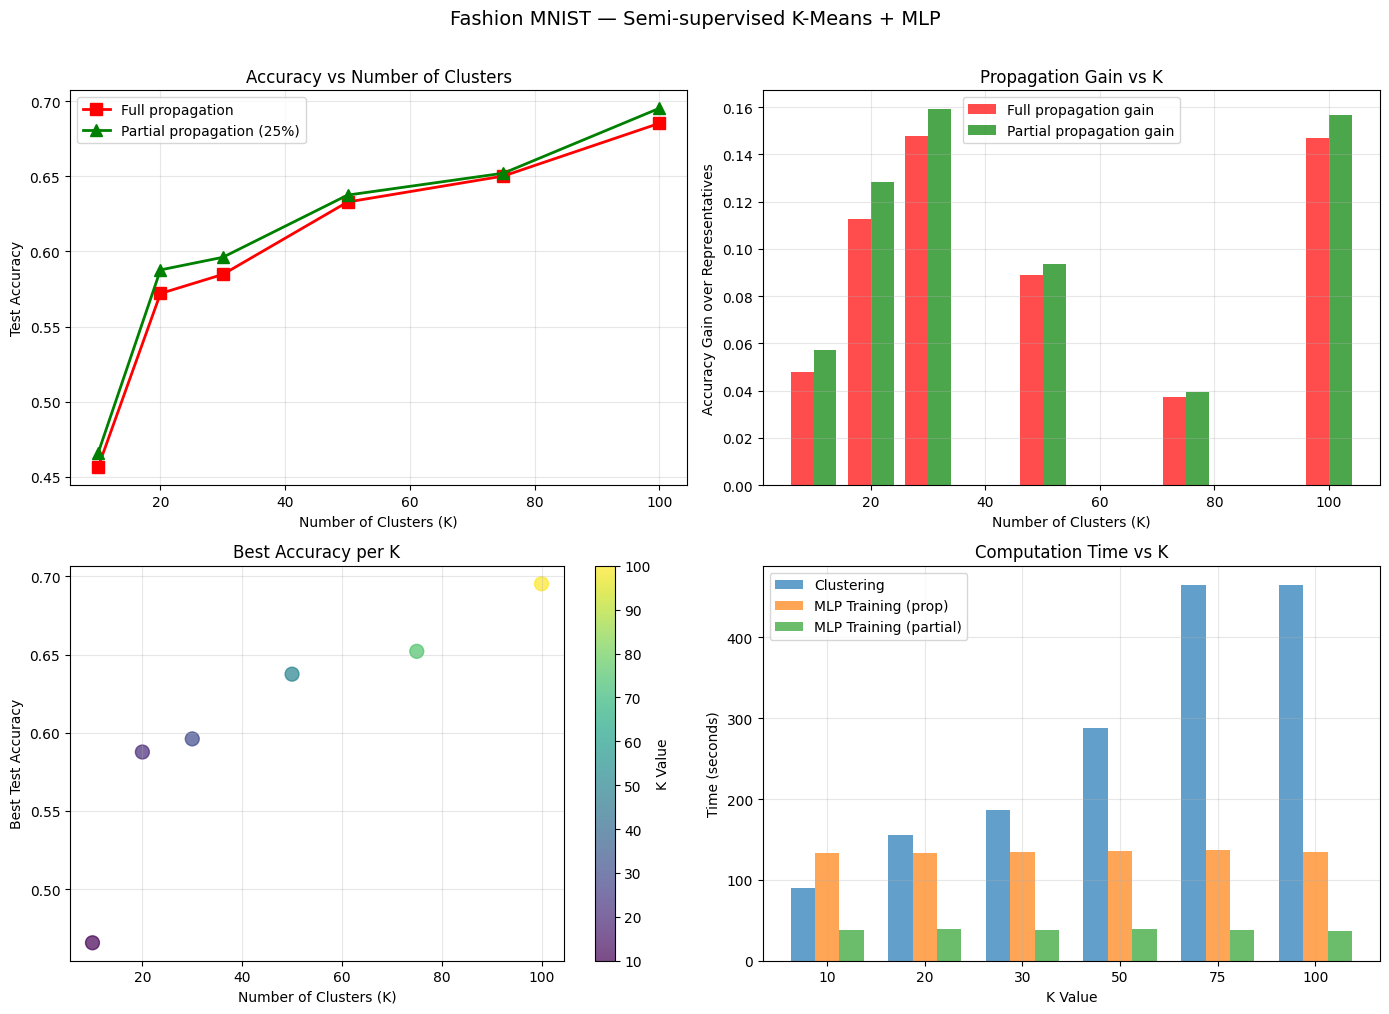

In [ ]:
# ─────────────────────────────────────────────
# Visualize results
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1 — Propagated vs Partial accuracy vs K (the two meaningful methods)
axes[0, 0].plot(results_df['K'], results_df['Propagated_Accuracy'],
                'rs-', linewidth=2, markersize=8, label='Full propagation')
axes[0, 0].plot(results_df['K'], results_df['Partial_Accuracy'],
                'g^-', linewidth=2, markersize=8, label='Partial propagation (25%)')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Accuracy vs Number of Clusters')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Panel 2 — Accuracy improvement from propagation over representatives
gap_full    = results_df['Propagated_Accuracy'] - results_df['Accuracy']
gap_partial = results_df['Partial_Accuracy']    - results_df['Accuracy']

axes[0, 1].bar(results_df['K'] - 2, gap_full,    width=4, label='Full propagation gain',    alpha=0.7, color='red')
axes[0, 1].bar(results_df['K'] + 2, gap_partial,  width=4, label='Partial propagation gain', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Accuracy Gain over Representatives')
axes[0, 1].set_title('Propagation Gain vs K')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Panel 3 — Best accuracy per K (scatter coloured by K)
best_acc_per_k = results_df[['Accuracy','Propagated_Accuracy','Partial_Accuracy']].max(axis=1)
sc = axes[1, 0].scatter(results_df['K'], best_acc_per_k,
                        c=results_df['K'], cmap='viridis', s=100, alpha=0.7)
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Best Test Accuracy')
axes[1, 0].set_title('Best Accuracy per K')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[1, 0], label='K Value')

# Panel 4 — Computation time comparison
bar_width = 0.25
x_pos = np.arange(len(results_df))
axes[1, 1].bar(x_pos - bar_width,   results_df['Clustering_Time'], bar_width,
               label='Clustering',             alpha=0.7)
axes[1, 1].bar(x_pos,               results_df['Prop_Time'],       bar_width,
               label='MLP Training (prop)',    alpha=0.7)
axes[1, 1].bar(x_pos + bar_width,   results_df['Partial_Time'],    bar_width,
               label='MLP Training (partial)', alpha=0.7)
axes[1, 1].set_xlabel('K Value')
axes[1, 1].set_ylabel('Time (seconds)')
axes[1, 1].set_title('Computation Time vs K')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(results_df['K'].tolist())
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Fashion MNIST — Semi-supervised K-Means + MLP', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("fashion_mnist_results.png", dpi=150)
plt.show()

---
### Best Model Analysis
Re-run the best-performing K configuration and examine its confusion matrix
and per-class classification report

In [ ]:
# ─────────────────────────────────────────────
# Best model — confusion matrix
# ─────────────────────────────────────────────


# Step 1: get best K
best_k = max(results, key=lambda k: results[k]['partial'])
print("Best K:", best_k)

# Step 2: rerun ONLY for this K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
X_dist = kmeans.fit_transform(X_train_flat)

rep_idx = X_dist.argmin(axis=0)
y_rep = y_train_full[rep_idx]

# label propagation
y_prop = np.empty(len(X_train_flat), dtype=np.int64)
for i in range(best_k):
    y_prop[kmeans.labels_ == i] = y_rep[i]

# partial mask (25%)
X_cluster_dist = X_dist[np.arange(len(X_train_flat)), kmeans.labels_]
partial_mask = np.zeros(len(X_train_flat), dtype=bool)

for i in range(best_k):
    in_cluster = (kmeans.labels_ == i)
    cutoff = np.percentile(X_cluster_dist[in_cluster], 25)
    partial_mask[in_cluster & (X_cluster_dist <= cutoff)] = True

# Step 3: train ONLY once
model = build_mlp()
model.fit(X_train_flat[partial_mask], y_prop[partial_mask],
          epochs=30, batch_size=32, verbose=0)

# Step 4: evaluate
y_pred = model.predict(X_test_flat).argmax(axis=1)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best K: 100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[844   4   6  36   2   1  73   3  31   0]
 [ 31 877  13  69   2   0   6   0   2   0]
 [ 29   3 548   4  28   1 366   0  21   0]
 [ 94   3   2 745  83   1  59   0  12   1]
 [ 26   5 228  22 206   0 496   0  17   0]
 [  1   0   0   1   0 676   0 273   5  44]
 [306   4 126  16  27   1 469   1  50   0]
 [  0   0   0   0   0  17   0 964   0  19]
 [  7   1  10   4   0  10  20  17 931   0]
 [  1   0   0   0   0  22   0 278   1 698]]
              precision    recall  f1-score   support

           0       0.63      0.84      0.72      1000
           1       0.98      0.88      0.92      1000
           2       0.59      0.55      0.57      1000
           3       0.83      0.74      0.79      1000
           4       0.59      0.21      0.31      1000
           5       0.93      0.68      0.78      1000
           6       0.31      0.47      0.38      1000
           7       0.63      0.96      0.76      1000
           8       0.87      

----
### Visualise Representative Images
Display the actual Fashion MNIST images selected as cluster representatives
for the best K — these are the only images whose labels are used for training



Visualising representative images for best K = 100


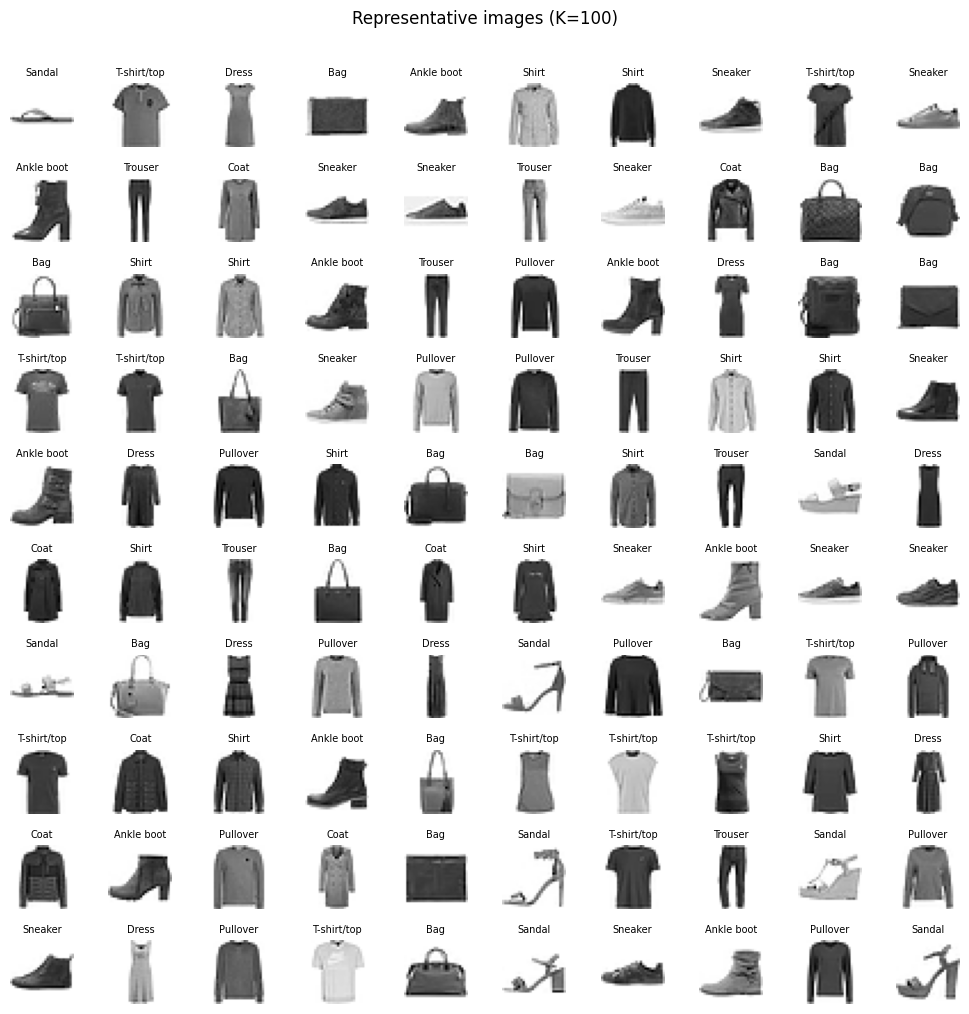

Representative images saved.


In [ ]:
# ─────────────────────────────────────────────
#  VISUALISE REPRESENTATIVE IMAGES (best K)
# ─────────────────────────────────────────────

best_K = max(results, key=lambda k: results[k]["partial"])
print(f"\nVisualising representative images for best K = {best_K}")

kmeans_best = KMeans(n_clusters=best_K, random_state=42, n_init=10)
X_dist_best = kmeans_best.fit_transform(X_train_flat)
rep_idx_best = X_dist_best.argmin(axis=0)

cols = min(best_K, 10)
rows = (best_K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.0, rows * 1.0))
axes = np.array(axes).flatten()
for i, idx in enumerate(rep_idx_best):
    axes[i].imshow(X_train_full[idx], cmap="binary")
    axes[i].set_title(class_names[y_train_full[idx]], fontsize=7)
    axes[i].axis("off")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Representative images (K={best_K})", y=1.01)
plt.tight_layout()
plt.savefig("fashion_mnist_representatives.png", dpi=150)
plt.show()
print("Representative images saved.")

---
### Final Summary Report
Generate a comprehensive summary of all experiments comparing baseline,
naive, and semi-supervised approaches

In [ ]:
# ─────────────────────────────────────────────
# FINAL SUMMARY TABLE (SAFE)
# ─────────────────────────────────────────────

import pandas as pd

# --- Build DataFrame from results ---
summary_df = pd.DataFrame([
    {
        "K": k,
        "Rep Only": v['representative'],
        "Propagated": v['propagated'],
        "Partial 25%": v['partial']
    }
    for k, v in results.items()
]).sort_values("K")

# --- Get best model ---
best_row = summary_df.loc[summary_df["Partial 25%"].idxmax()]
best_k = int(best_row["K"])
best_acc = best_row["Partial 25%"]

# --- SAFELY get baseline & naive values ---
try:
    baseline = baseline_acc
except:
    baseline = baseline_accuracy  # fallback if different name

try:
    naive = naive_acc
except:
    naive = naive_accuracy  # fallback

# --- Print summary ---
print("\n" + "="*70)
print("                 FINAL PERFORMANCE SUMMARY")
print("="*70)

print(summary_df.to_string(index=False, float_format="%.4f"))

print("="*70)
print(f"Baseline (all labels) : {baseline:.4f}")
print(f"Naive (50 samples)    : {naive:.4f}")
print("-"*70)

print(f"Best K                : {best_k}")
print(f"Best Accuracy         : {best_acc:.4f}")
print(f"Improvement (naive)   : {best_acc - naive:.4f}")
print(f"Gap to full baseline  : {baseline - best_acc:.4f}")

print("="*70)



                 FINAL PERFORMANCE SUMMARY
  K  Rep Only  Propagated  Partial 25%
 10    0.4084      0.4563       0.4657
 20    0.4595      0.5720       0.5877
 30    0.4369      0.5847       0.5961
 50    0.5438      0.6329       0.6375
 75    0.6127      0.6502       0.6521
100    0.5385      0.6853       0.6953
Baseline (all labels) : 0.8744
Naive (50 samples)    : 0.4941
----------------------------------------------------------------------
Best K                : 100
Best Accuracy         : 0.6953
Improvement (naive)   : 0.2012
Gap to full baseline  : 0.1791


---
---


## *DATA SET 2: Semi-Supervised Learning on Overhead MNIST Dataset*


 Technique: K-Means Clustering + SVM Classification

 Goal: Select representative labeled samples using clustering to train an SVM

 Experiment: Different K values (clusters) to find optimal subset size

 ----

###  Objective
 This experiment implements a semi-supervised learning approach using K-Means clustering
 to select a small, representative subset of labeled data for training an SVM classifier.


---

 ### Methodology
 1. Use K-Means clustering on unlabeled features to identify natural groupings
 2. For each cluster, select the sample closest to the cluster center
 3. Use only these selected samples (with their labels) to train an SVM
 4. Evaluate performance on held-out test data
 5. Compare results across different K values


---
 ### Experiment Parameters
 - K values: 30, 50, 70, 100, 150, 200
 - Baseline: SVM trained on 10% of random labeled data
 - Full training: SVM trained on all training data (for reference)

---
###  Setup and Import Libraries
 This cell imports all necessary libraries for data processing, clustering, and classification

In [ ]:
# ─────────────────────────────────────────────
#Import all required libraries
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from collections import Counter
import time as t
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42) # Setting random seed for reproducibility

---
### Mount Google Drive and Load Data
 Mount Google Drive to access the Overhead MNIST dataset

In [ ]:
# ─────────────────────────────────────────────
# Mount Google Drive and load the dataset
# ─────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Define the path to your dataset
data_path = '/content/drive/MyDrive/DMML Assignment/overhead'

In [ ]:
print("Files in directory:")
print(os.listdir(data_path))

Files in directory:
['testing', 'train.csv', 'training', 'classes.csv', 'labels.csv', 'test.csv']


In [ ]:
# ─────────────────────────────────────────────
# Load the training and testing data
# ─────────────────────────────────────────────

train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))
classes_df = pd.read_csv(os.path.join(data_path, 'classes.csv'))

# Display dataset information
print(f"\n Training data shape: {train_df.shape}")
print(f" Test data shape: {test_df.shape}")
print(f"\n Class labels:")
print(classes_df)

# Check class distribution in training set
print(f"\n Class distribution in training set:")
class_dist = train_df['label'].value_counts().sort_index()
for label, count in class_dist.items():
    class_name = classes_df[classes_df.iloc[:,0] == label].iloc[0,1] if label in classes_df.iloc[:,0].values else "Unknown"
    print(f"  Class {label} ({class_name}): {count} samples")


 Training data shape: (8519, 785)
 Test data shape: (1065, 785)

 Class labels:
           class  label  train_count  test_count
0            car      0          888         112
1         harbor      1          889         111
2     helicopter      2          655          82
3  oil_gas_field      3          888         110
4    parking_lot      4          888         112
5          plane      5          889         111
6    runway_mark      6          801         100
7           ship      7          889         111
8        stadium      8          843         105
9   storage_tank      9          889         111

 Class distribution in training set:
  Class 0 (Unknown): 888 samples
  Class 1 (Unknown): 889 samples
  Class 2 (Unknown): 655 samples
  Class 3 (Unknown): 888 samples
  Class 4 (Unknown): 888 samples
  Class 5 (Unknown): 889 samples
  Class 6 (Unknown): 801 samples
  Class 7 (Unknown): 889 samples
  Class 8 (Unknown): 843 samples
  Class 9 (Unknown): 889 samples


---
###  Data Preprocessing
Separate features and labels, then normalize the pixel values

In [ ]:
# ─────────────────────────────────────────────
# Prepare data for clustering and classification
# ─────────────────────────────────────────────

# Separate features (pixel values) and labels
X_train_full = train_df.drop('label', axis=1).values  # Pixel features
y_train_full = train_df['label'].values               # Labels

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

print(f" Training features shape: {X_train_full.shape}")
print(f" Training labels shape: {y_train_full.shape}")
print(f" Test features shape: {X_test.shape}")
print(f" Test labels shape: {y_test.shape}")

# Normalize pixel values to [0, 1] range for better clustering performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

print(f"\n Pixel value range after normalization:")
print(f"  Training - Min: {X_train_scaled.min():.3f}, Max: {X_train_scaled.max():.3f}")
print(f"  Test - Min: {X_test_scaled.min():.3f}, Max: {X_test_scaled.max():.3f}")

 Training features shape: (8519, 784)
 Training labels shape: (8519,)
 Test features shape: (1065, 784)
 Test labels shape: (1065,)

 Pixel value range after normalization:
  Training - Min: -1.883, Max: 2.315
  Test - Min: -1.882, Max: 2.315


---
###  Define Semi-Supervised Learning Function
 This function implements K-Means clustering + SVM classification

In [ ]:
# ─────────────────────────────────────────────
# Function for semi-supervised learning with K-Means and SVM (Revised)
# ─────────────────────────────────────────────

def semi_supervised_clustering_svm(X_unlabeled, y_unlabeled, X_test, y_test,
                                   n_clusters, samples_per_cluster=1, random_state=42):
    """
    Perform semi-supervised learning using K-Means clustering + SVM.

    Parameters:
    - X_unlabeled: All training features (will be clustered)
    - y_unlabeled: All training labels (used only for simulation – in real life these are unknown)
    - X_test: Test features
    - y_test: Test labels
    - n_clusters: Number of K-Means clusters
    - samples_per_cluster: Number of samples to select from each cluster
    - random_state: Random seed

    Returns:
    - y_pred: Predictions on test set
    - selected_indices: Indices of selected samples from unlabeled data
    - clustering_time: Time taken for clustering
    - training_time: Time taken for SVM training
    """

    print(f"\n{'='*60}")
    print(f" Experiment: K = {n_clusters} clusters")
    print(f"{'='*60}")

    # Step 1: Perform K-Means clustering on unlabeled data
    print(f" Clustering {X_unlabeled.shape[0]} samples into {n_clusters} clusters...")
    start_time = t.time()

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    cluster_labels = kmeans.fit_predict(X_unlabeled)

    clustering_time = t.time() - start_time
    print(f" Clustering completed in {clustering_time:.2f} seconds")

    # Step 2: Select representative samples from each cluster
    print(f" Selecting {samples_per_cluster} sample(s) from each cluster...")
    selected_indices = []

    for cluster_id in range(n_clusters):
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        if len(cluster_indices) > 0:
            cluster_center = kmeans.cluster_centers_[cluster_id]
            distances = np.linalg.norm(X_unlabeled[cluster_indices] - cluster_center, axis=1)
            n_samples_to_take = min(samples_per_cluster, len(cluster_indices))
            closest_indices = cluster_indices[np.argsort(distances)[:n_samples_to_take]]
            selected_indices.extend(closest_indices)

    print(f" Selected {len(selected_indices)} samples for labeling")

    # Step 3: Create training set from selected samples
    # In a real scenario, a human would label these selected samples.
    # Here we use the true labels from y_unlabeled to simulate that process.
    X_selected = X_unlabeled[selected_indices]
    y_selected = y_unlabeled[selected_indices]

    print(f" Final training set size: {len(X_selected)} samples")

    # Step 4: Train SVM classifier
    print(f" Training SVM on {len(X_selected)} samples...")
    start_time = t.time()

    svm = SVC(random_state=random_state)
    svm.fit(X_selected, y_selected)

    training_time = t.time() - start_time
    print(f" SVM training completed in {training_time:.2f} seconds")

    # Step 5: Evaluate on test set
    print(f" Evaluating on test set ({len(X_test)} samples)...")
    y_pred = svm.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    return y_pred, selected_indices, clustering_time, training_time

---
### Baseline - Using All Labeled Data
Train SVM on the complete training set to establish a baseline

In [ ]:
# Diagnostic: Inspect classes_df structure
print("Classes DataFrame:")
print(classes_df)
print("\nData types:")
print(classes_df.dtypes)
print("\nAll values:")
for i in range(len(classes_df)):
    print(f"Row {i}: {classes_df.iloc[i].values}")

Classes DataFrame:
           class  label  train_count  test_count
0            car      0          888         112
1         harbor      1          889         111
2     helicopter      2          655          82
3  oil_gas_field      3          888         110
4    parking_lot      4          888         112
5          plane      5          889         111
6    runway_mark      6          801         100
7           ship      7          889         111
8        stadium      8          843         105
9   storage_tank      9          889         111

Data types:
class          object
label           int64
train_count     int64
test_count      int64
dtype: object

All values:
Row 0: ['car' np.int64(0) np.int64(888) np.int64(112)]
Row 1: ['harbor' np.int64(1) np.int64(889) np.int64(111)]
Row 2: ['helicopter' np.int64(2) np.int64(655) np.int64(82)]
Row 3: ['oil_gas_field' np.int64(3) np.int64(888) np.int64(110)]
Row 4: ['parking_lot' np.int64(4) np.int64(888) np.int64(112)]
Row 5: ['pla

In [ ]:
# ─────────────────────────────────────────────
# Baseline performance with all training data
# ─────────────────────────────────────────────

print("\n" + "="*60)
print(" BASELINE: Training SVM on ALL labeled data")
print("="*60)

# Train SVM on full training set
start_time = t.time()

baseline_svm = SVC(random_state=42)
baseline_svm.fit(X_train_scaled, y_train_full)

baseline_training_time = t.time() - start_time
print(f" Training completed in {baseline_training_time:.2f} seconds")

# Evaluate on test set
print(f" Evaluating on test set...")
y_pred_baseline = baseline_svm.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"\n Baseline Test Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")

# Extract class names correctly from classes_df
# The first column contains class names (strings), second column contains numeric codes
class_names_list = []
for i in range(len(classes_df)):
    val = classes_df.iloc[i, 0]  # First column
    if isinstance(val, str):
        class_names_list.append(val)

print(f"\n Extracted class names: {class_names_list}")

# If still empty, try alternative: maybe classes_df is transposed or different
if len(class_names_list) == 0:
    print("Warning: No strings found in first column, trying all columns...")
    for col in classes_df.columns:
        for val in classes_df[col]:
            if isinstance(val, str) and val not in class_names_list:
                class_names_list.append(val)
    print(f"Alternative extraction: {class_names_list}")

# Ensure we have exactly 10 class names (for labels 0-9)
# If we have more, take first 10; if fewer, pad with generic names
if len(class_names_list) >= 10:
    class_names_list = class_names_list[:10]
else:
    # Fallback: create generic names
    class_names_list = [f"Class_{i}" for i in range(10)]
    print(f"Using fallback class names: {class_names_list}")

# Display detailed classification report
print(f"\n Detailed Classification Report (Baseline):")
unique_labels = sorted(np.unique(y_test))
print(classification_report(y_test, y_pred_baseline,
                          labels=unique_labels,
                          target_names=class_names_list[:len(unique_labels)]))

# Also compute and display per-class accuracy
print("\n Per-Class Accuracy:")
for i, class_name in enumerate(class_names_list[:10]):
    class_mask = (y_test == i)
    if class_mask.sum() > 0:
        class_acc = accuracy_score(y_test[class_mask], y_pred_baseline[class_mask])
        print(f"  {class_name:15s}: {class_acc:.4f} ({class_acc*100:.2f}%)")


 BASELINE: Training SVM on ALL labeled data
 Training completed in 17.21 seconds
 Evaluating on test set...

 Baseline Test Accuracy: 0.7164 (71.64%)

 Extracted class names: ['car', 'harbor', 'helicopter', 'oil_gas_field', 'parking_lot', 'plane', 'runway_mark', 'ship', 'stadium', 'storage_tank']

 Detailed Classification Report (Baseline):
               precision    recall  f1-score   support

          car       0.87      0.81      0.84       112
       harbor       0.79      0.76      0.77       111
   helicopter       0.91      0.82      0.86        82
oil_gas_field       0.59      0.85      0.69       110
  parking_lot       0.57      0.41      0.48       112
        plane       0.82      0.89      0.85       111
  runway_mark       0.57      0.76      0.65       100
         ship       0.91      0.87      0.89       111
      stadium       0.54      0.38      0.45       105
 storage_tank       0.66      0.63      0.65       111

     accuracy                           0.72     

---
### Experiment with Different K Values
 Test various numbers of clusters for semi-supervised learning

In [ ]:
# ─────────────────────────────────────────────
# Compare performance across different cluster sizes
# ─────────────────────────────────────────────

# Define K values to test (start with smaller values to save time)
k_values = [50, 100, 150, 200, 300]
samples_per_cluster = 1  # Select 1 sample per cluster

# Store results
results = []

print("\n" + "="*60)
print(" SEMI-SUPERVISED LEARNING EXPERIMENTS")
print("="*60)
print(f"Sampling: {samples_per_cluster} sample(s) per cluster")
print(f"K values: {k_values}")
print("="*60)

for k in k_values:
    y_pred, selected_idx, cluster_time, train_time = semi_supervised_clustering_svm(
        X_unlabeled=X_train_scaled,
        y_unlabeled=y_train_full,
        X_test=X_test_scaled,
        y_test=y_test,
        n_clusters=k,
        samples_per_cluster=samples_per_cluster
    )

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'K': k,
        'Selected_Samples': len(selected_idx),
        'Accuracy': accuracy,
        'Clustering_Time': cluster_time,
        'Training_Time': train_time
    })

    print(f"\n K={k} summary: {len(selected_idx)} samples → accuracy = {accuracy:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print(" EXPERIMENT RESULTS SUMMARY")
print("="*60)
print(results_df.to_string(index=False))


 SEMI-SUPERVISED LEARNING EXPERIMENTS
Sampling: 1 sample(s) per cluster
K values: [50, 100, 150, 200, 300]

 Experiment: K = 50 clusters
 Clustering 8519 samples into 50 clusters...
 Clustering completed in 20.05 seconds
 Selecting 1 sample(s) from each cluster...
 Selected 50 samples for labeling
 Final training set size: 50 samples
 Training SVM on 50 samples...
 SVM training completed in 0.00 seconds
 Evaluating on test set (1065 samples)...

 Test Accuracy: 0.3324 (33.24%)

 K=50 summary: 50 samples → accuracy = 0.3324

 Experiment: K = 100 clusters
 Clustering 8519 samples into 100 clusters...
 Clustering completed in 38.99 seconds
 Selecting 1 sample(s) from each cluster...
 Selected 100 samples for labeling
 Final training set size: 100 samples
 Training SVM on 100 samples...
 SVM training completed in 0.01 seconds
 Evaluating on test set (1065 samples)...

 Test Accuracy: 0.4047 (40.47%)

 K=100 summary: 100 samples → accuracy = 0.4047

 Experiment: K = 150 clusters
 Clusterin

---
### Visualization - Compare Performance

 Create visualizations to compare different K values

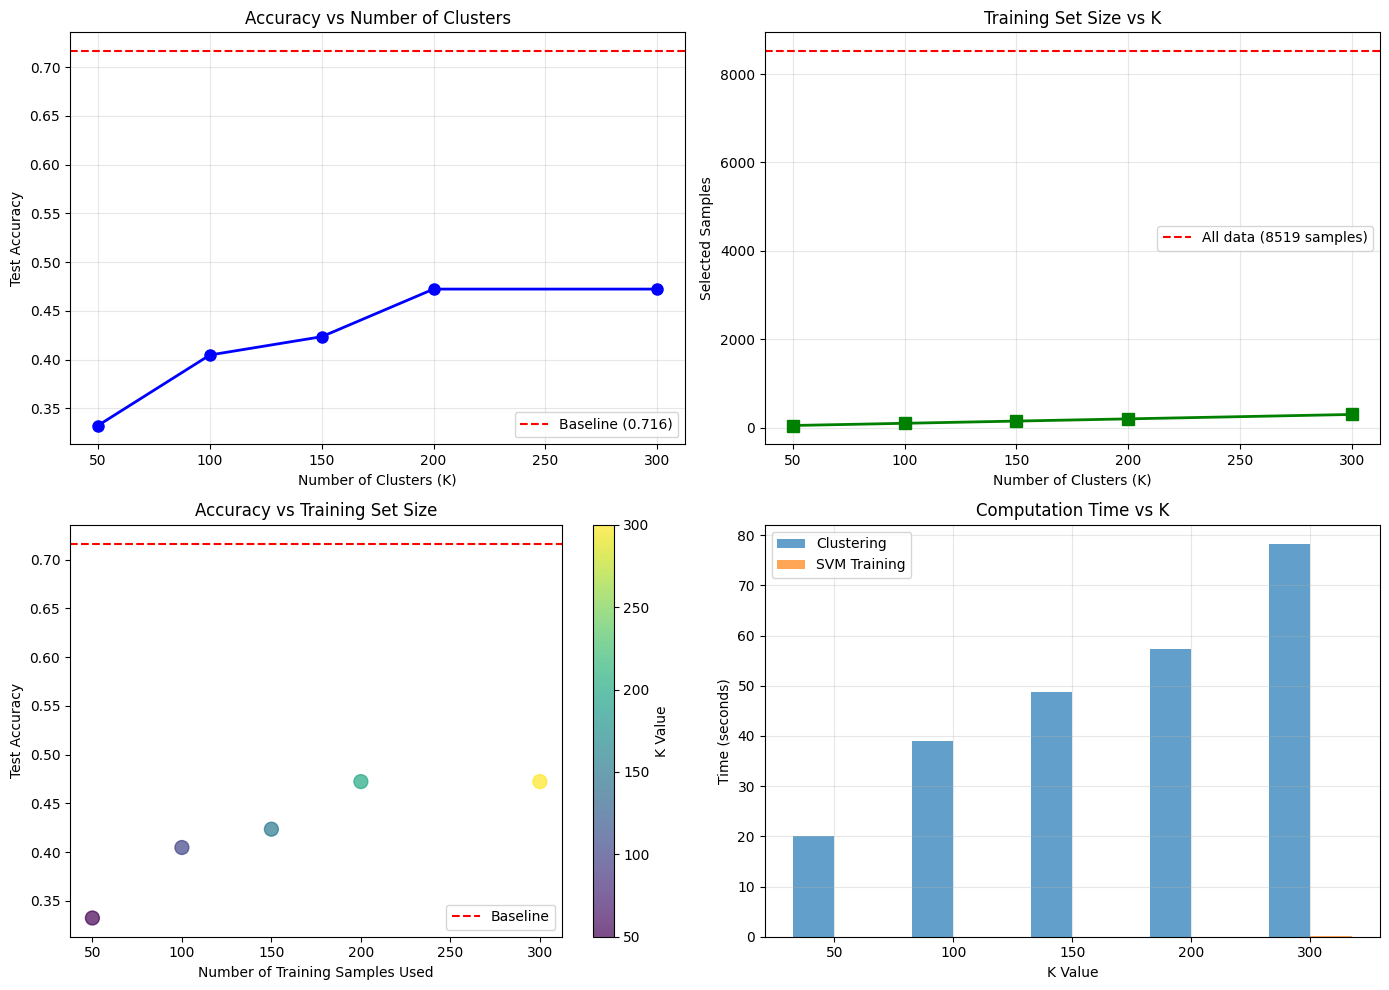

In [ ]:
# ─────────────────────────────────────────────
# Visualize results
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy vs K
axes[0,0].plot(results_df['K'], results_df['Accuracy'], 'bo-', linewidth=2, markersize=8)
axes[0,0].axhline(y=baseline_accuracy, color='r', linestyle='--', label=f'Baseline ({baseline_accuracy:.3f})')
axes[0,0].set_xlabel('Number of Clusters (K)')
axes[0,0].set_ylabel('Test Accuracy')
axes[0,0].set_title('Accuracy vs Number of Clusters')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

# Selected samples vs K
axes[0,1].plot(results_df['K'], results_df['Selected_Samples'], 'gs-', linewidth=2, markersize=8)
axes[0,1].axhline(y=len(y_train_full), color='r', linestyle='--', label=f'All data ({len(y_train_full)} samples)')
axes[0,1].set_xlabel('Number of Clusters (K)')
axes[0,1].set_ylabel('Selected Samples')
axes[0,1].set_title('Training Set Size vs K')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# Accuracy vs training samples
sc = axes[1,0].scatter(results_df['Selected_Samples'], results_df['Accuracy'],
                       c=results_df['K'], cmap='viridis', s=100, alpha=0.7)
axes[1,0].axhline(y=baseline_accuracy, color='r', linestyle='--', label='Baseline')
axes[1,0].set_xlabel('Number of Training Samples Used')
axes[1,0].set_ylabel('Test Accuracy')
axes[1,0].set_title('Accuracy vs Training Set Size')
axes[1,0].legend()
plt.colorbar(sc, ax=axes[1,0], label='K Value')

# Time comparison
bar_width = 0.35
x_pos = np.arange(len(k_values))
axes[1,1].bar(x_pos - bar_width/2, results_df['Clustering_Time'], bar_width, label='Clustering', alpha=0.7)
axes[1,1].bar(x_pos + bar_width/2, results_df['Training_Time'], bar_width, label='SVM Training', alpha=0.7)
axes[1,1].set_xlabel('K Value')
axes[1,1].set_ylabel('Time (seconds)')
axes[1,1].set_title('Computation Time vs K')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(k_values)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
### Best Model Analysis
 Analyze the best performing model and show confusion matrix

In [ ]:
# ─────────────────────────────────────────────
# Best model analysis
# ─────────────────────────────────────────────
best_idx = results_df['Accuracy'].idxmax()
best_k = results_df.loc[best_idx, 'K']
best_acc = results_df.loc[best_idx, 'Accuracy']

print("="*60)
print(f" BEST MODEL: K = {best_k}, Accuracy = {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*60)

 BEST MODEL: K = 200, Accuracy = 0.4723 (47.23%)


In [ ]:

# Re-run best model to get predictions
y_pred_best, selected_best, _, _ = semi_supervised_clustering_svm(
    X_unlabeled=X_train_scaled,
    y_unlabeled=y_train_full,
    X_test=X_test_scaled,
    y_test=y_test,
    n_clusters=int(best_k),
    samples_per_cluster=1
)



 Experiment: K = 200 clusters
 Clustering 8519 samples into 200 clusters...
 Clustering completed in 58.55 seconds
 Selecting 1 sample(s) from each cluster...
 Selected 200 samples for labeling
 Final training set size: 200 samples
 Training SVM on 200 samples...
 SVM training completed in 0.03 seconds
 Evaluating on test set (1065 samples)...

 Test Accuracy: 0.4723 (47.23%)


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.title(f'Confusion Matrix - Best Model (K={int(best_k)})', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_names_list))

---
### Analysis of Selected Samples
 Analyze which samples were selected by K-Means clustering

In [ ]:
# ─────────────────────────────────────────────
# Class distribution of selected samples
# ─────────────────────────────────────────────
selected_labels = y_train_full[selected_best]
selected_counts = Counter(selected_labels)

print("\nSelected samples per class:")
print("-" * 40)
for class_id in range(10):
    class_name = class_names_list[class_id]
    count = selected_counts.get(class_id, 0)
    total = class_dist[class_id]
    pct = 100 * count / total if total > 0 else 0
    print(f"{class_name:15s}: {count:3d}/{total:3d} ({pct:5.1f}%)")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(class_names_list, class_dist.values)
ax1.set_title('Original Training Set')
ax1.set_xticklabels(class_names_list, rotation=45, ha='right')
ax1.set_ylabel('Count')

ax2.bar(class_names_list, [selected_counts.get(i,0) for i in range(10)])
ax2.set_title(f'Selected Samples (K={int(best_k)})')
ax2.set_xticklabels(class_names_list, rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
###  Final Summary Report
Generate comprehensive summary of all experiments

In [ ]:
# ─────────────────────────────────────────────
# Final report
# ─────────────────────────────────────────────
print("\n" + "="*80)
print(" " * 25 + "FINAL PROJECT SUMMARY")
print("="*80)

print(f"\nDataset: Overhead MNIST")
print(f"Total training samples: {len(y_train_full)}")
print(f"Test samples: {len(y_test)}")
print(f"Classes: {len(class_names_list)}")

print(f"\nBaseline SVM (all data):")
print(f"  Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  Training time: {baseline_training_time:.2f} sec")

print(f"\nBest Semi-Supervised Model (K={int(best_k)}):")
print(f"  Training samples used: {len(selected_best)} ({100*len(selected_best)/len(y_train_full):.1f}% of full set)")
print(f"  Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"  Improvement over baseline: {best_acc - baseline_accuracy:+.4f}")
print(f"  Labeling effort saved: {len(y_train_full) - len(selected_best)} samples ({100*(1-len(selected_best)/len(y_train_full)):.1f}% reduction)")

print("\n" + "="*80)
print(" " * 30 + "END OF EXPERIMENT")
print("="*80)


---
----